In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

BASE_DIR = "/content/drive/MyDrive/banana leaf/SHOWROV AZAM BANANA RESEARCH"

print("Dataset path:")
print(BASE_DIR)

print("\nไฟล์/โฟลเดอร์ภายใน:")
print(os.listdir(BASE_DIR))

Dataset path:
/content/drive/MyDrive/banana leaf/SHOWROV AZAM BANANA RESEARCH

ไฟล์/โฟลเดอร์ภายใน:
['desktop.ini', 'test', 'validation', 'train']


In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
import os

BASE_DIR = "/content/drive/MyDrive/banana leaf/SHOWROV AZAM BANANA RESEARCH"

for root, dirs, files in os.walk(BASE_DIR):
    level = root.replace(BASE_DIR, "").count(os.sep)
    indent = "  " * level
    print(indent + os.path.basename(root) + "/")

SHOWROV AZAM BANANA RESEARCH/
  test/
    Chewing insect damage on banana leaf/
    Healthy Banana  leaf/
    Banana Skipper Damage/
    Black and Yellow Sigatoka/
    Panama Wilt Disease/
  validation/
    Chewing insect damage on banana leaf/
    Panama Wilt Disease/
    Healthy Banana  leaf/
    Banana Skipper Damage/
    Black and Yellow Sigatoka/
  train/
    Banana Skipper Damage/
    Panama Wilt Disease/
    Chewing insect damage on banana leaf/
    Healthy Banana  leaf/
    Black and Yellow Sigatoka/


In [ ]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Path Dataset
BASE_DIR = "/content/drive/MyDrive/banana leaf/SHOWROV AZAM BANANA RESEARCH"

train_dir = os.path.join(BASE_DIR, "train")
test_dir = os.path.join(BASE_DIR, "test")

# ตรวจสอบว่าโฟลเดอร์มีจริง
print("Train path:", train_dir)
print("Test path:", test_dir)

print("Train exists:", os.path.exists(train_dir))
print("Test exists:", os.path.exists(test_dir))

Train path: /content/drive/MyDrive/banana leaf/SHOWROV AZAM BANANA RESEARCH/train
Test path: /content/drive/MyDrive/banana leaf/SHOWROV AZAM BANANA RESEARCH/test
Train exists: True
Test exists: True


In [ ]:
# Transform สำหรับ Train
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

# Transform สำหรับ Validation / Test
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

In [ ]:
# โหลดข้อมูลทั้งหมดจาก train
full_dataset = datasets.ImageFolder(
    train_dir,
    transform=train_transform
)

# จำนวนข้อมูล
total_size = len(full_dataset)
train_size = int(0.8 * total_size)
val_size = total_size - train_size

# แบ่ง Train 80% / Validation 20%
train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# โหลด Test
test_dataset = datasets.ImageFolder(
    test_dir,
    transform=val_transform
)

print("Classes:", full_dataset.classes)
print("Number of classes:", len(full_dataset.classes))
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Classes: ['Banana Skipper Damage', 'Black and Yellow Sigatoka', 'Chewing insect damage on banana leaf', 'Healthy Banana  leaf', 'Panama Wilt Disease']
Number of classes: 5
Train: 3380
Validation: 845
Test: 535


In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print("DataLoader พร้อมใช้งานแล้ว")

DataLoader พร้อมใช้งานแล้ว


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

# ตรวจสอบ GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

# จำนวน Class
num_classes = len(full_dataset.classes)

# โหลด ResNet50
weights = models.ResNet50_Weights.DEFAULT

model = models.resnet50(weights=weights)

# เปลี่ยนชั้นสุดท้ายให้ตรงกับจำนวน Class ของเรา
model.fc = nn.Linear(
    model.fc.in_features,
    num_classes
)

# ส่งโมเดลไป GPU
model = model.to(device)

print("Number of classes:", num_classes)
print("Classes:", full_dataset.classes)

Device: cuda
Number of classes: 5
Classes: ['Banana Skipper Damage', 'Black and Yellow Sigatoka', 'Chewing insect damage on banana leaf', 'Healthy Banana  leaf', 'Panama Wilt Disease']


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

print("Optimizer พร้อมใช้งาน")

Optimizer พร้อมใช้งาน


In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        # ล้าง gradient
        optimizer.zero_grad()

        # ทำนาย
        outputs = model(images)

        # คำนวณ Loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # ปรับ weights
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [ ]:
def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [ ]:
import torch

print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA: True
GPU: Tesla T4


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
NUM_EPOCHS = 20

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

best_val_acc = 0.0

BEST_MODEL_PATH = "/content/best_resnet50_banana.pth"

for epoch in range(NUM_EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    # เก็บผล
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_acc*100:.2f}% "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_acc*100:.2f}%"
    )

    # บันทึกโมเดลที่ดีที่สุด
    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH
        )

        print("   >>> บันทึก Best Model แล้ว")

print("\nTraining เสร็จแล้ว")
print("Best Validation Accuracy:", best_val_acc * 100, "%")

Epoch [1/20] | Train Loss: 0.4379 | Train Acc: 88.93% | Val Loss: 0.0715 | Val Acc: 97.28%
   >>> บันทึก Best Model แล้ว
Epoch [2/20] | Train Loss: 0.0556 | Train Acc: 97.90% | Val Loss: 0.0450 | Val Acc: 97.99%
   >>> บันทึก Best Model แล้ว
Epoch [3/20] | Train Loss: 0.0464 | Train Acc: 97.49% | Val Loss: 0.0418 | Val Acc: 97.87%
Epoch [4/20] | Train Loss: 0.0560 | Train Acc: 97.54% | Val Loss: 0.0547 | Val Acc: 97.99%
Epoch [5/20] | Train Loss: 0.0352 | Train Acc: 98.22% | Val Loss: 0.0410 | Val Acc: 97.99%
Epoch [6/20] | Train Loss: 0.0390 | Train Acc: 98.02% | Val Loss: 0.0466 | Val Acc: 97.40%
Epoch [7/20] | Train Loss: 0.0448 | Train Acc: 97.75% | Val Loss: 0.0363 | Val Acc: 98.34%
   >>> บันทึก Best Model แล้ว
Epoch [8/20] | Train Loss: 0.0312 | Train Acc: 98.20% | Val Loss: 0.0368 | Val Acc: 97.99%
Epoch [9/20] | Train Loss: 0.0305 | Train Acc: 98.20% | Val Loss: 0.0351 | Val Acc: 97.87%
Epoch [10/20] | Train Loss: 0.0329 | Train Acc: 98.28% | Val Loss: 0.0573 | Val Acc: 97.16%

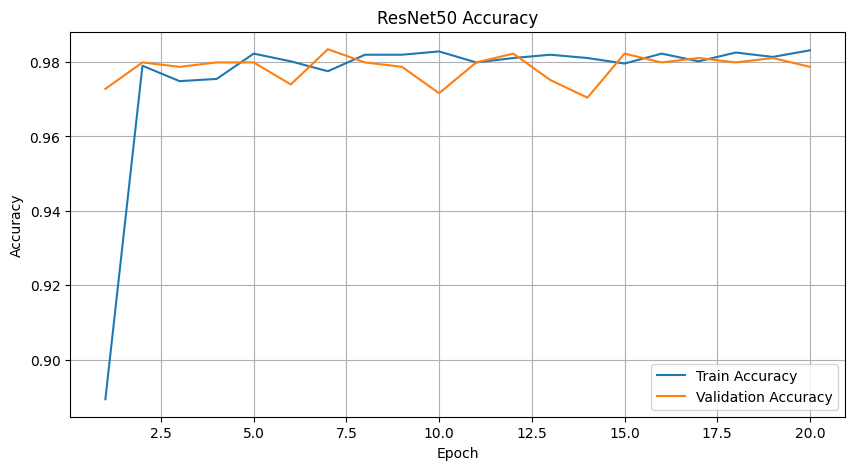

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, NUM_EPOCHS + 1),
    train_accuracies,
    label="Train Accuracy"
)

plt.plot(
    range(1, NUM_EPOCHS + 1),
    val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet50 Accuracy")

plt.legend()
plt.grid()

plt.show()

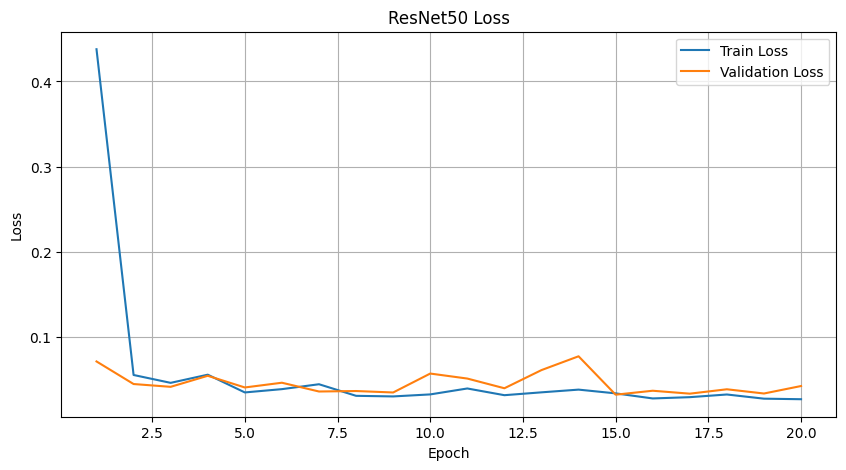

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, NUM_EPOCHS + 1),
    train_losses,
    label="Train Loss"
)

plt.plot(
    range(1, NUM_EPOCHS + 1),
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 Loss")

plt.legend()
plt.grid()

plt.show()

In [ ]:
model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("โหลด Best ResNet50 สำเร็จ")

โหลด Best ResNet50 สำเร็จ


In [ ]:
test_loss, test_acc = validate(
    model,
    test_loader,
    criterion,
    device
)

print("================================")
print("ResNet50 Test Results")
print("================================")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc*100:.2f}%")

ResNet50 Test Results
Test Loss     : 0.0415
Test Accuracy : 98.69%


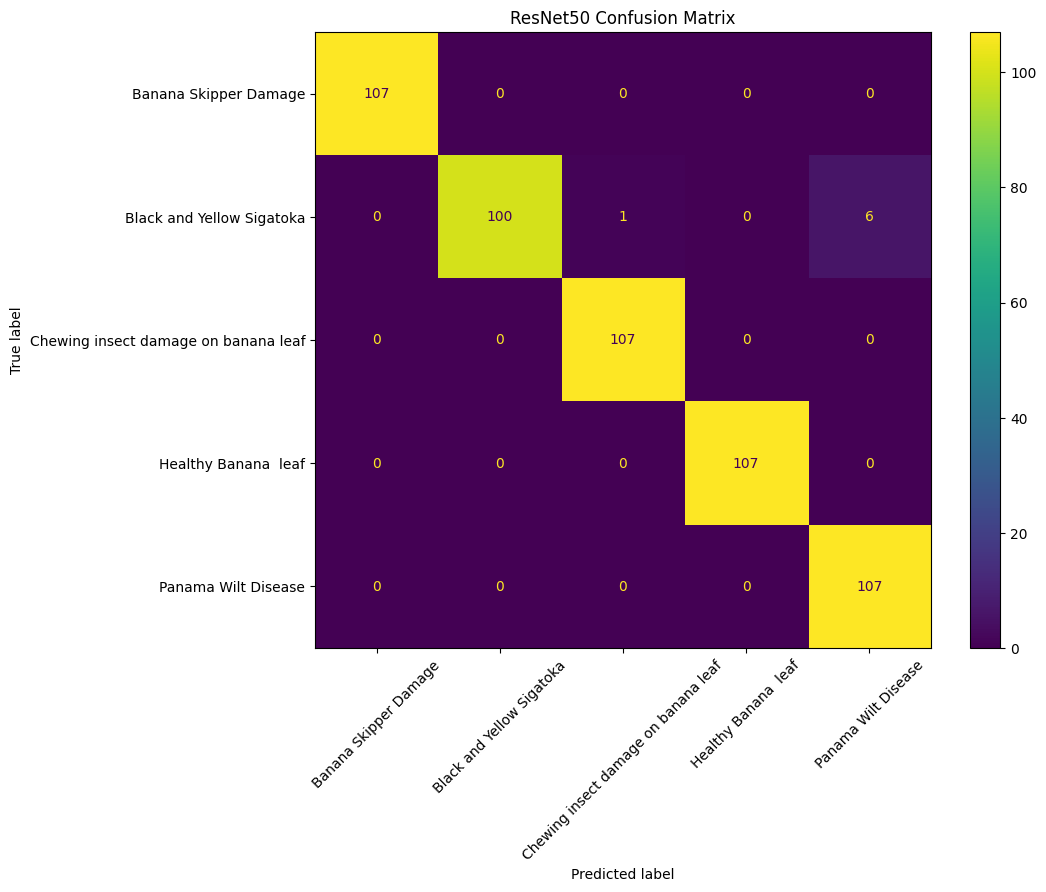

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

# สร้าง Confusion Matrix
cm = confusion_matrix(
    y_true,
    y_pred
)

# แสดงผล
fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=full_dataset.classes
)

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title("ResNet50 Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=full_dataset.classes,
    digits=4
)

print(report)

                                      precision    recall  f1-score   support

               Banana Skipper Damage     1.0000    1.0000    1.0000       107
           Black and Yellow Sigatoka     1.0000    0.9346    0.9662       107
Chewing insect damage on banana leaf     0.9907    1.0000    0.9953       107
                Healthy Banana  leaf     1.0000    1.0000    1.0000       107
                 Panama Wilt Disease     0.9469    1.0000    0.9727       107

                            accuracy                         0.9869       535
                           macro avg     0.9875    0.9869    0.9869       535
                        weighted avg     0.9875    0.9869    0.9869       535



In [ ]:
DRIVE_MODEL_PATH = "/content/drive/MyDrive/banana leaf/best_resnet50_banana.pth"

torch.save(
    model.state_dict(),
    DRIVE_MODEL_PATH
)

print("บันทึกโมเดลเรียบร้อย")
print(DRIVE_MODEL_PATH)

บันทึกโมเดลเรียบร้อย
/content/drive/MyDrive/banana leaf/best_resnet50_banana.pth


In [ ]:
import pandas as pd

history = pd.DataFrame({
    "Epoch": range(1, NUM_EPOCHS + 1),
    "Train Loss": train_losses,
    "Train Accuracy": train_accuracies,
    "Validation Loss": val_losses,
    "Validation Accuracy": val_accuracies
})

history_path = "/content/drive/MyDrive/banana leaf/resnet50_training_history.csv"

history.to_csv(
    history_path,
    index=False
)

print("บันทึก Training History แล้ว")

บันทึก Training History แล้ว


Saving Screenshot 2026-09-04 130451.png to Screenshot 2026-09-04 130451.png


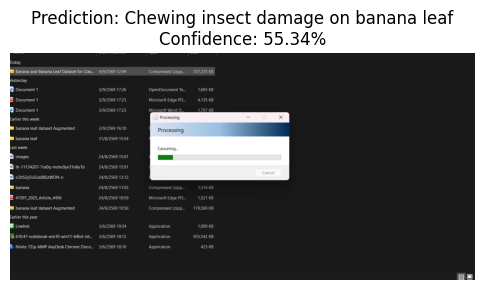

ผลการทำนาย: Chewing insect damage on banana leaf
ความมั่นใจ: 55.34%


In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files

# =========================
# 1. ตั้งค่า
# =========================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

num_classes = len(full_dataset.classes)

# =========================
# 2. สร้าง ResNet50
# =========================

model = models.resnet50(weights=None)

model.fc = nn.Linear(
    model.fc.in_features,
    num_classes
)

# =========================
# 3. โหลดโมเดลที่ Train แล้ว
# =========================

model.load_state_dict(
    torch.load(
        "/content/best_resnet50_banana.pth",
        map_location=device
    )
)

model = model.to(device)
model.eval()

# =========================
# 4. เตรียมรูป
# =========================

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

# =========================
# 5. อัปโหลดรูป
# =========================

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

image = Image.open(
    image_path
).convert("RGB")

# =========================
# 6. ทำนาย
# =========================

image_tensor = transform(
    image
).unsqueeze(0).to(device)

with torch.no_grad():

    output = model(
        image_tensor
    )

    probabilities = torch.softmax(
        output,
        dim=1
    )

    confidence, predicted = torch.max(
        probabilities,
        1
    )

# =========================
# 7. แสดงผล
# =========================

predicted_class = full_dataset.classes[
    predicted.item()
]

confidence = confidence.item() * 100

plt.figure(figsize=(6, 6))

plt.imshow(image)

plt.axis("off")

plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.show()

print("ผลการทำนาย:", predicted_class)
print(f"ความมั่นใจ: {confidence:.2f}%")